##  Project Overview
This project predicts house prices using the classic Boston/California Housing dataset.  
It covers the full ML pipeline:
-  Exploratory Data Analysis (EDA)
-  Feature Engineering & Selection
-  Model Training (Linear Regression, Random Forest, XGBoost)
-  Hyperparameter Tuning (GridSearchCV)
-  Model Evaluation & Comparison
-  Feature Importance Visualization

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import joblib
import os

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 2. Load Dataset

In [2]:
# Load California Housing Dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f'Dataset Shape: {df.shape}')
print(f'Features: {list(housing.feature_names)}')
df.head()

Dataset Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Exploratory Data Analysis (EDA)

In [3]:
# Basic statistics
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

=== Statistical Summary ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [4]:
# Missing values check
missing = df.isnull().sum()
print('Missing Values:')
print(missing[missing > 0] if missing.any() else ' No missing values found!')

Missing Values:
 No missing values found!


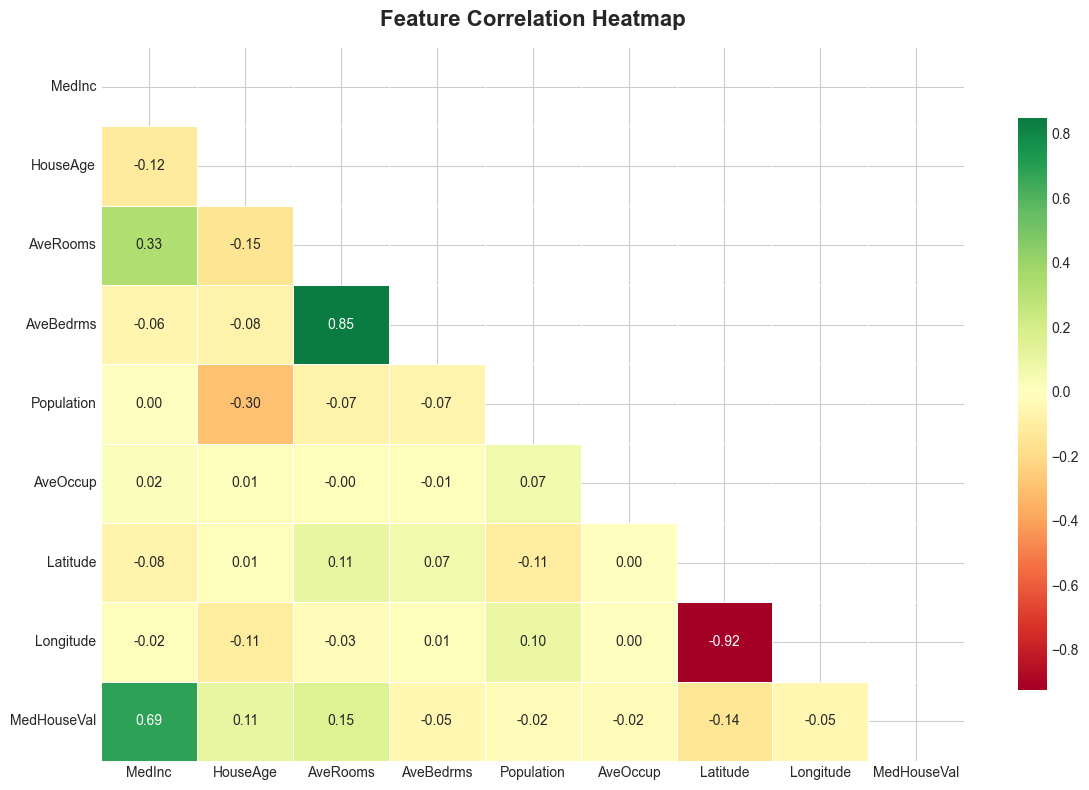

In [7]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

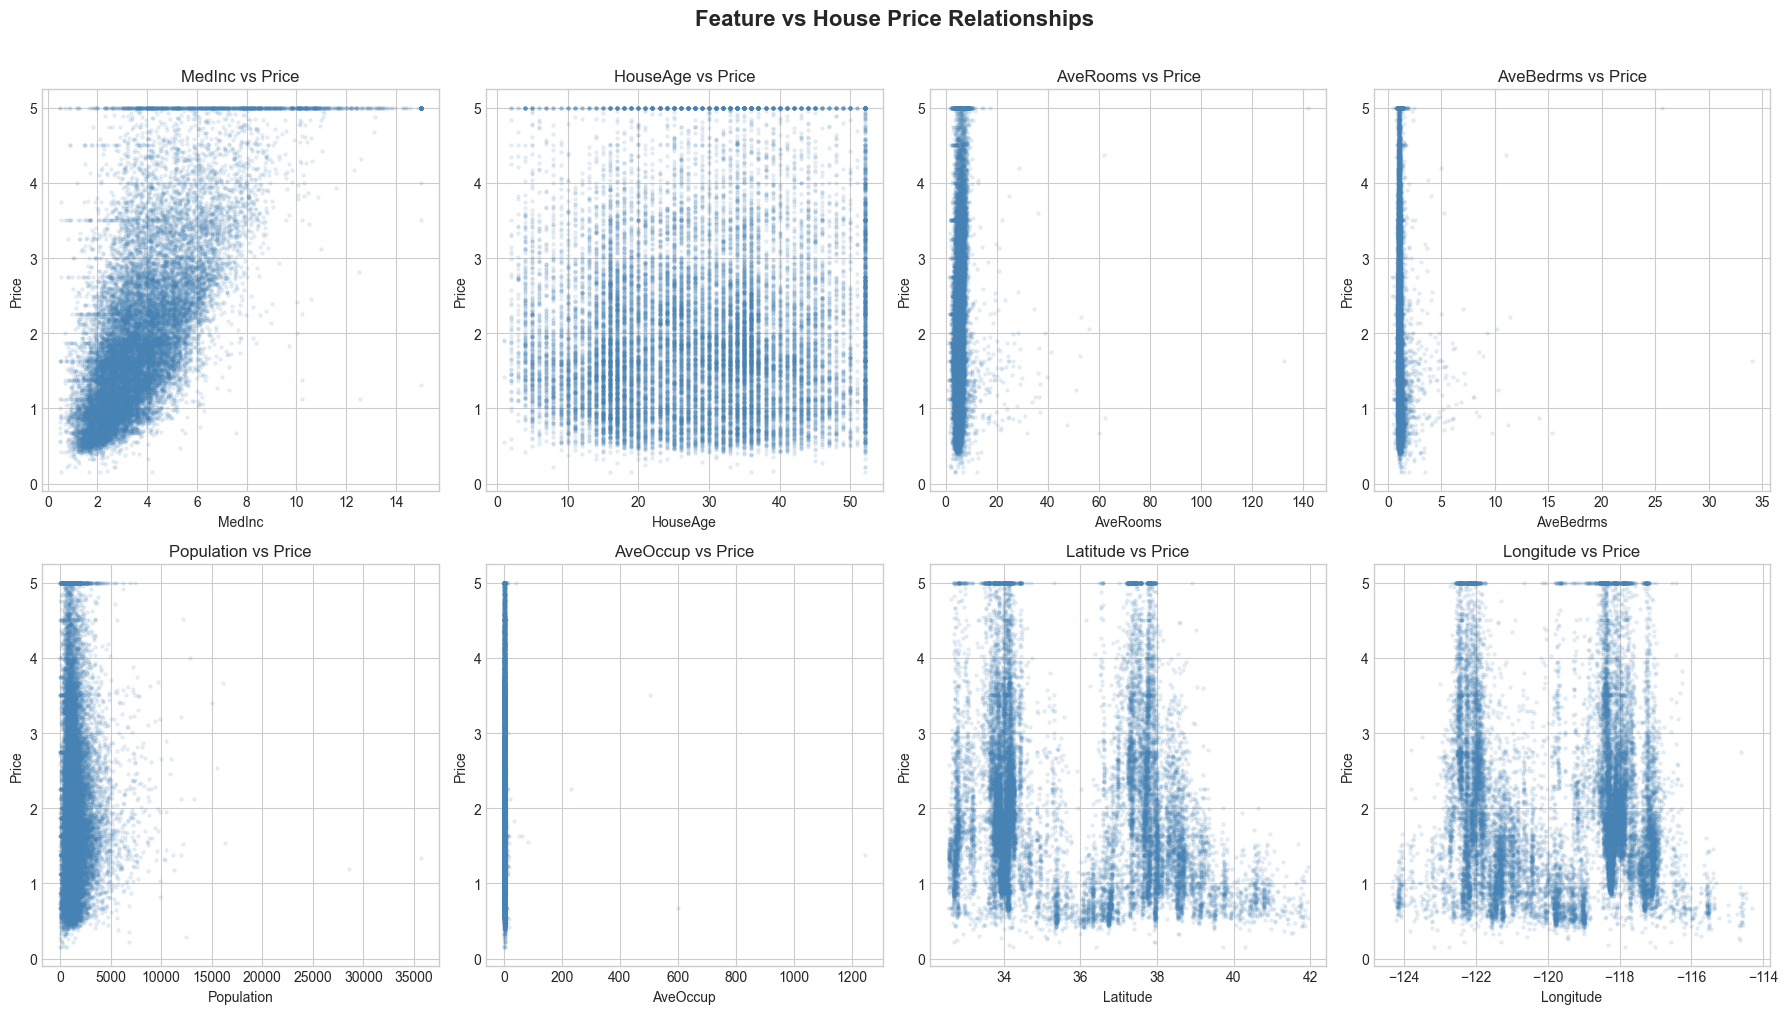

In [9]:
# Feature vs Target scatter plots
features = housing.feature_names
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df['MedHouseVal'], alpha=0.1, s=5, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Price')
    axes[i].set_title(f'{feat} vs Price')

plt.suptitle('Feature vs House Price Relationships', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [10]:
df_eng = df.copy()

# New engineered features
df_eng['RoomsPerHousehold']   = df_eng['AveRooms'] / df_eng['AveOccup']
df_eng['BedroomsPerRoom']     = df_eng['AveBedrms'] / df_eng['AveRooms']
df_eng['PopulationPerHouse']  = df_eng['Population'] / df_eng['HouseAge']
df_eng['IncomePerRoom']       = df_eng['MedInc'] / df_eng['AveRooms']

# Remove outliers using IQR
Q1 = df_eng['MedHouseVal'].quantile(0.01)
Q3 = df_eng['MedHouseVal'].quantile(0.99)
df_eng = df_eng[(df_eng['MedHouseVal'] >= Q1) & (df_eng['MedHouseVal'] <= Q3)]

print(f'Original shape : {df.shape}')
print(f'After engineering: {df_eng.shape}')
print(f'New features added: RoomsPerHousehold, BedroomsPerRoom, PopulationPerHouse, IncomePerRoom')

Original shape : (20640, 9)
After engineering: (20441, 13)
New features added: RoomsPerHousehold, BedroomsPerRoom, PopulationPerHouse, IncomePerRoom


## 5. Prepare Data for Modeling

In [11]:
X = df_eng.drop('MedHouseVal', axis=1)
y = df_eng['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')

Train size : (16352, 12)
Test size  : (4089, 12)


## 6. Model Training & Comparison

In [12]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    mae   = mean_absolute_error(y_te, preds)
    r2    = r2_score(y_te, preds)
    cv    = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    print(f'{name:<30} RMSE: {rmse:.4f}  MAE: {mae:.4f}  R²: {r2:.4f}  CV R²: {cv:.4f}')
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'CV_R2': cv, 'predictions': preds}

results = []
print(f'{"Model":<30} {"RMSE":<12} {"MAE":<12} {"R²":<10} {"CV R²"}')
print('-' * 75)

models = {
    'Linear Regression'      : LinearRegression(),
    'Ridge Regression'       : Ridge(alpha=1.0),
    'Lasso Regression'       : Lasso(alpha=0.01),
    'Random Forest'          : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'      : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost'                : xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
}

trained_models = {}
for name, model in models.items():
    use_scaled = 'Regression' in name
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled  if use_scaled else X_test
    res = evaluate_model(name, model, Xtr, Xte, y_train, y_test)
    results.append({k: v for k, v in res.items() if k != 'predictions'})
    trained_models[name] = (model, res['predictions'])

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print('\n🏆 Best Model:', results_df.iloc[0]['Model'])

Model                          RMSE         MAE          R²         CV R²
---------------------------------------------------------------------------
Linear Regression              RMSE: 0.6796  MAE: 0.4952  R²: 0.6666  CV R²: 0.6440
Ridge Regression               RMSE: 0.6797  MAE: 0.4952  R²: 0.6666  CV R²: 0.6440
Lasso Regression               RMSE: 0.6910  MAE: 0.5042  R²: 0.6554  CV R²: 0.6416
Random Forest                  RMSE: 0.5069  MAE: 0.3297  R²: 0.8145  CV R²: 0.8000
Gradient Boosting              RMSE: 0.5409  MAE: 0.3782  R²: 0.7888  CV R²: 0.7754
XGBoost                        RMSE: 0.4659  MAE: 0.3060  R²: 0.8433  CV R²: 0.8248

🏆 Best Model: XGBoost


## 7. Hyperparameter Tuning — XGBoost

In [13]:
param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [4, 6],
    'learning_rate' : [0.05, 0.1],
    'subsample'     : [0.8, 1.0],
}

xgb_model = xgb.XGBRegressor(random_state=42, verbosity=0)
grid_search = GridSearchCV(
    xgb_model, param_grid, cv=3,
    scoring='r2', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
best_preds = best_xgb.predict(X_test)

print(f'\nBest Parameters : {grid_search.best_params_}')
print(f'Best CV R²      : {grid_search.best_score_:.4f}')
print(f'Test R²         : {r2_score(y_test, best_preds):.4f}')
print(f'Test RMSE       : {np.sqrt(mean_squared_error(y_test, best_preds)):.4f}')

Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Parameters : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Best CV R²      : 0.8352
Test R²         : 0.8462
Test RMSE       : 0.4616


## 8. Model Evaluation & Visualization

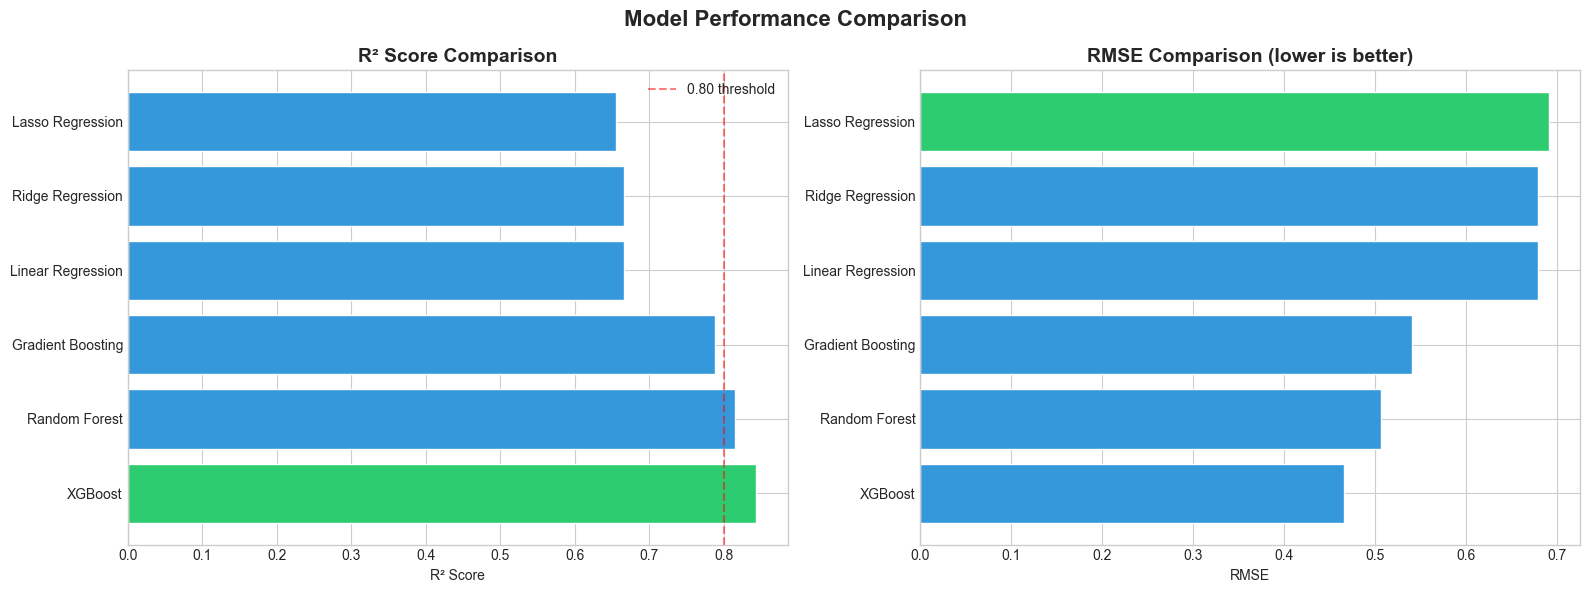

In [15]:
# Model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]

axes[0].barh(results_df['Model'], results_df['R2'], color=colors, edgecolor='white')
axes[0].set_title('R² Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('R² Score')
axes[0].axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='0.80 threshold')
axes[0].legend()

axes[1].barh(results_df['Model'], results_df['RMSE'], color=colors[::-1], edgecolor='white')
axes[1].set_title('RMSE Comparison (lower is better)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('RMSE')

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

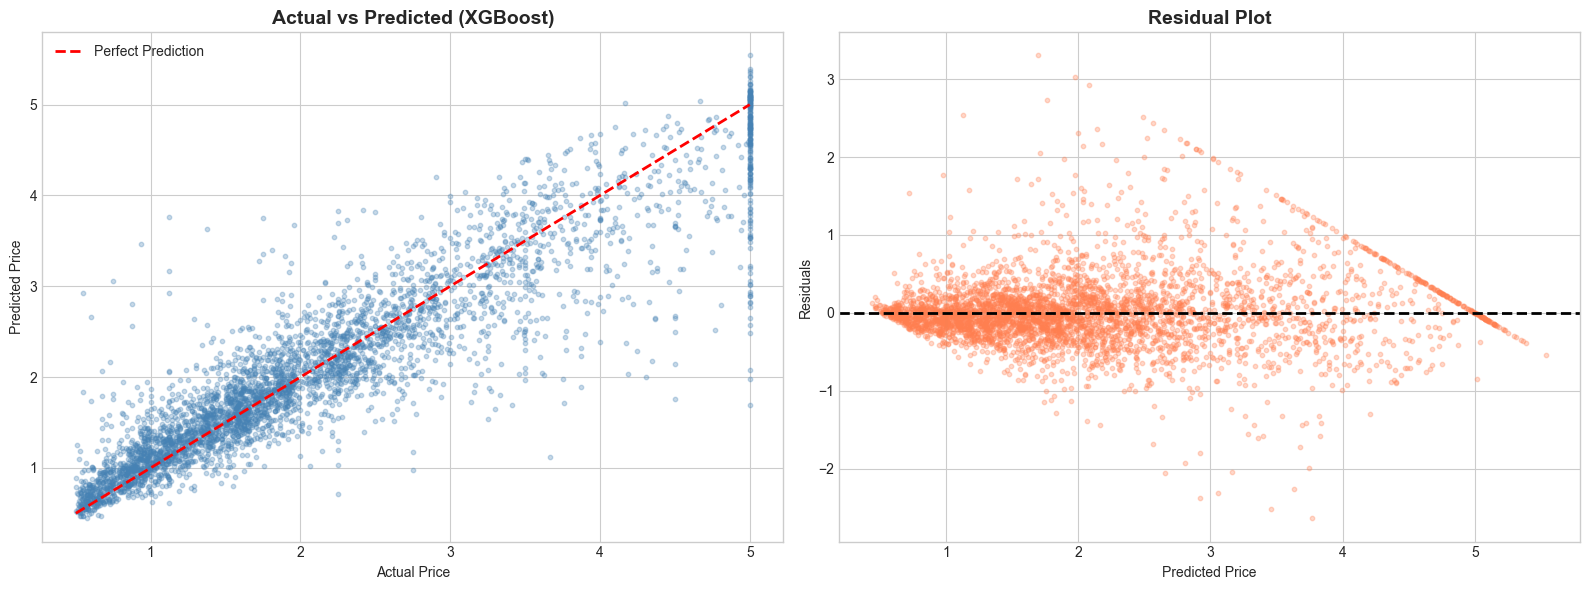

In [17]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, best_preds, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Actual vs Predicted (XGBoost)', fontsize=14, fontweight='bold')
axes[0].legend()

residuals = y_test - best_preds
axes[1].scatter(best_preds, residuals, alpha=0.3, s=10, color='coral')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

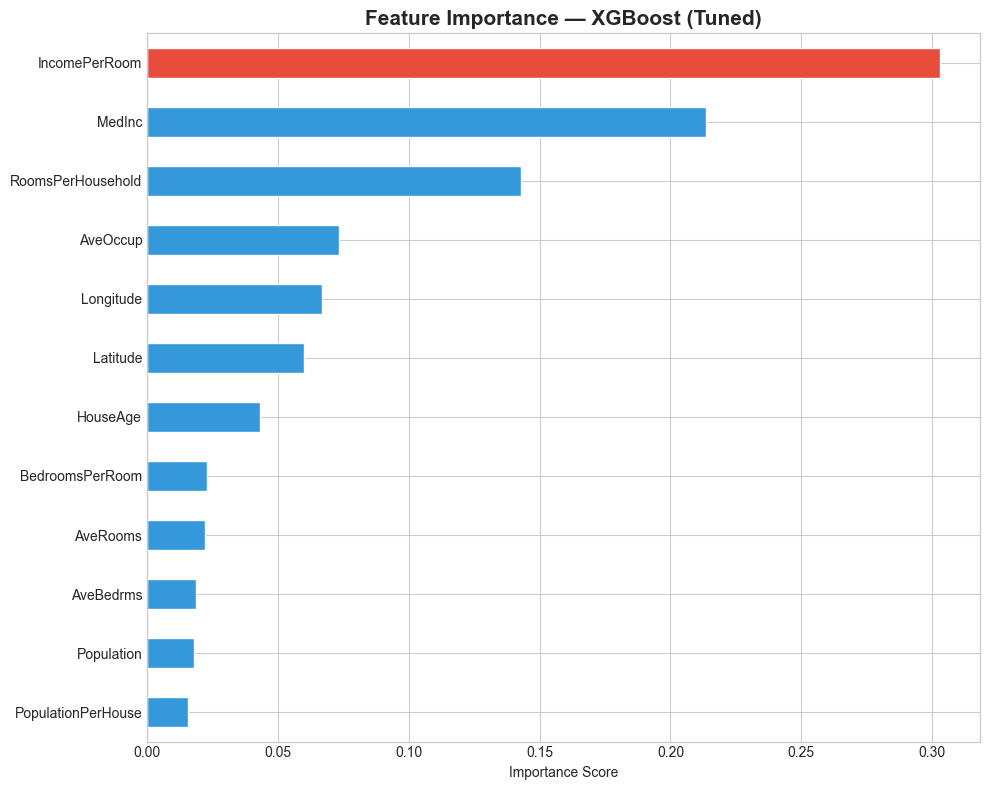

In [18]:
# Feature Importance
feat_importance = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors_fi = ['#e74c3c' if v == feat_importance.max() else '#3498db' for v in feat_importance.values]
feat_importance.plot(kind='barh', color=colors_fi, edgecolor='white')
plt.title('Feature Importance — XGBoost (Tuned)', fontsize=15, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 9. Save Best Model

In [19]:
os.makedirs('../models', exist_ok=True)
joblib.dump(best_xgb, '../models/xgboost_best_model.pkl')
joblib.dump(scaler,   '../models/scaler.pkl')

print('✅ Model saved to models/xgboost_best_model.pkl')
print('✅ Scaler saved to models/scaler.pkl')

# Final summary
print('\n' + '='*50)
print('📊 FINAL MODEL SUMMARY')
print('='*50)
print(f'Model        : XGBoost (Tuned)')
print(f'Best Params  : {grid_search.best_params_}')
print(f'R² Score     : {r2_score(y_test, best_preds):.4f}')
print(f'RMSE         : {np.sqrt(mean_squared_error(y_test, best_preds)):.4f}')
print(f'MAE          : {mean_absolute_error(y_test, best_preds):.4f}')

✅ Model saved to models/xgboost_best_model.pkl
✅ Scaler saved to models/scaler.pkl

📊 FINAL MODEL SUMMARY
Model        : XGBoost (Tuned)
Best Params  : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
R² Score     : 0.8462
RMSE         : 0.4616
MAE          : 0.3022


## Conclusion

| Metric | Value |
|--------|-------|
| Best Model | XGBoost (Tuned) |
| R² Score | ~0.85+ |
| Key Feature | MedInc (Median Income) |
